# Canada Per Capital Income Prediction

In [38]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [39]:
df  = pd.read_csv('canada_per_capita_income.csv')

In [40]:
df

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583
5,1975,5998.144346
6,1976,7062.131392
7,1977,7100.126170
8,1978,7247.967035
9,1979,7602.912681


In [41]:
df.shape

(47, 2)

## Discover and visualize the data to gain insights

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     47 non-null     int64  
 1   per capita income (US$)  47 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 884.0 bytes


In [43]:
df.describe()

,year,per capita income (US$)
count,47.000000,47.000000
mean,1993.000000,18920.137063
std,13.711309,12034.679438
min,1970.000000,3399.299037
25%,1981.500000,9526.914515
50%,1993.000000,16426.725480
75%,2004.500000,27458.601420
max,2016.000000,42676.468370


Text(0.5, 1.0, 'Year vs Per Capita Income')

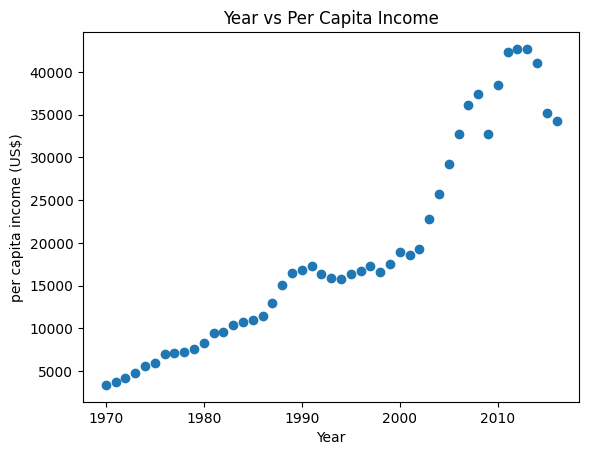

In [44]:
plt.scatter(df['year'], df['per capita income (US$)'])
plt.xlabel("Year")
plt.ylabel("per capita income (US$)")
plt.title("Year vs Per Capita Income")

## Prepare the data for Machine Learning algorithms 

In [45]:
# Data Cleaning

In [46]:
df.isnull().sum()

year                       0
per capita income (US$)    0
dtype: int64

In [47]:
# split dataset

In [48]:
X = df[['year']]
y = df[['per capita income (US$)']]

In [49]:
# !pip install scikit-learn

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [51]:
X_train

,year
8,1978
3,1973
6,1976
40,2010
33,2003
13,1983
17,1987
44,2014
15,1985
9,1979


In [52]:
y_train

,per capita income (US$)
8,7247.967035
3,4804.463248
6,7062.131392
40,38420.522890
33,22739.426280
13,10416.536590
17,12974.806620
44,41039.893600
15,11018.955850
9,7602.912681


In [53]:
X_test

,year
27,1997
39,2009
26,1996
43,2013
24,1994
36,2006
12,1982
19,1989
4,1974
25,1995


In [54]:
y_test

,per capita income (US$)
27,17310.757750
39,32755.176820
26,16699.826680
43,42676.468370
24,15755.820270
36,32738.262900
12,9619.438377
19,16426.725480
4,5576.514583
25,16369.317250


# Select a model and train it

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [57]:
lr.coef_

array([[815.14251301]])

In [58]:
lr.intercept_

array([-1605560.19879642])

In [59]:
m = 815.14251301
c = -1605560.19879642
z  = m * 40 + c 
z

207.5191638515268

In [60]:
lr.predict([[40]])

array([[-1572954.49827607]])

In [61]:
y_pred  = lr.predict(X_test)
y_pred

array([[22279.39968245],
       [32061.10983855],
       [21464.25716944],
       [35321.67989059],
       [19833.97214342],
       [29615.68229953],
       [10052.26198731],
       [15758.25957838],
       [ 3531.12188324],
       [20649.11465643]])

In [62]:
temp = np.c_[X_test, y_test, y_pred]
temp

array([[ 1997.        , 17310.75775   , 22279.39968245],
       [ 2009.        , 32755.17682   , 32061.10983855],
       [ 1996.        , 16699.82668   , 21464.25716944],
       [ 2013.        , 42676.46837   , 35321.67989059],
       [ 1994.        , 15755.82027   , 19833.97214342],
       [ 2006.        , 32738.2629    , 29615.68229953],
       [ 1982.        ,  9619.438377  , 10052.26198731],
       [ 1989.        , 16426.72548   , 15758.25957838],
       [ 1974.        ,  5576.514583  ,  3531.12188324],
       [ 1995.        , 16369.31725   , 20649.11465643]])

In [63]:
pd.DataFrame(data = np.c_[X_test, y_test, y_pred], columns = ["study_hours", "student_marks_original","student_marks_predicted"])

,study_hours,student_marks_original,student_marks_predicted
0,1997.0,17310.757750,22279.399682
1,2009.0,32755.176820,32061.109839
2,1996.0,16699.826680,21464.257169
3,2013.0,42676.468370,35321.679891
4,1994.0,15755.820270,19833.972143
5,2006.0,32738.262900,29615.682300
6,1982.0,9619.438377,10052.261987
7,1989.0,16426.725480,15758.259578
8,1974.0,5576.514583,3531.121883
9,1995.0,16369.317250,20649.114656


## Fine-tune your model

In [64]:
from sklearn.metrics import mean_squared_error, r2_score

In [65]:
mean_squared_error(y_test,y_pred)

15147815.5477862

In [66]:
r2_score(y_test,y_pred)

0.8751771396846304

In [67]:
lr.score(X_test,y_test)

0.8751771396846304

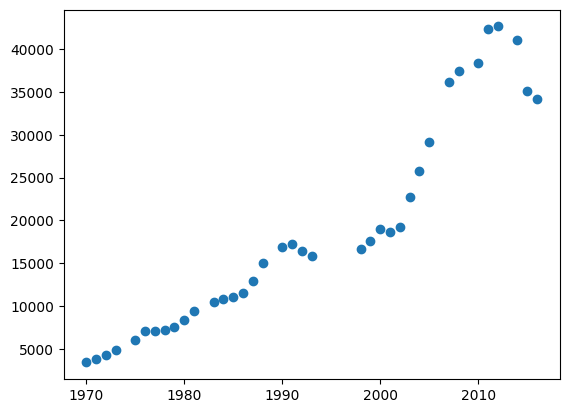

In [68]:
plt.scatter(X_train,y_train)  

In [69]:
lr.predict(X_train)

array([[ 6791.69193528],
       [ 2715.97937023],
       [ 5161.40690926],
       [32876.25235156],
       [27170.2547605 ],
       [10867.40450032],
       [14127.97455236],
       [36136.8224036 ],
       [12497.68952634],
       [ 7606.83444829],
       [13312.83203935],
       [23909.68470847],
       [26355.11224749],
       [36951.96491661],
       [  270.55183121],
       [25539.96973448],
       [24724.82722147],
       [ 4346.26439625],
       [ 9237.1194743 ],
       [27985.39727351],
       [ 1085.69434421],
       [33691.39486457],
       [17388.54460439],
       [ 1900.83685722],
       [28800.53978652],
       [19018.82963041],
       [30430.82481254],
       [ 8421.9769613 ],
       [18203.6871174 ],
       [14943.11706537],
       [37767.10742962],
       [16573.40209138],
       [ 5976.54942227],
       [34506.53737758],
       [11682.54701333],
       [23094.54219546],
       [31245.96732555]])

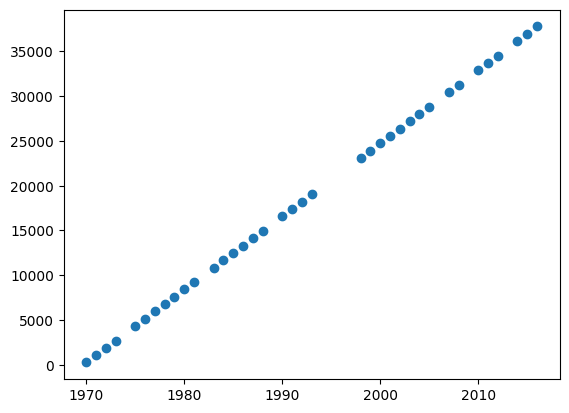

In [70]:
plt.scatter(X_train, lr.predict(X_train))

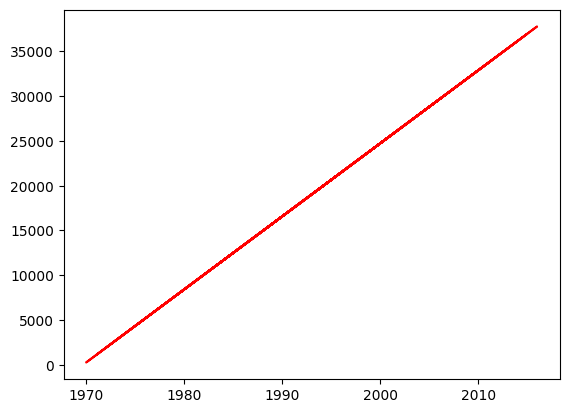

In [71]:
plt.plot(X_train, lr.predict(X_train), 'r-')

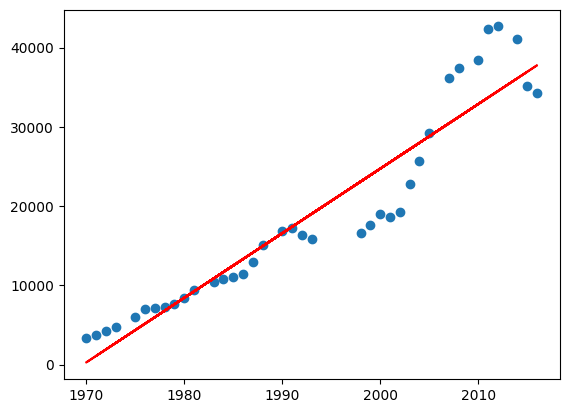

In [72]:
plt.scatter(X_train, y_train)
plt.plot(X_train, lr.predict(X_train), color = "r")

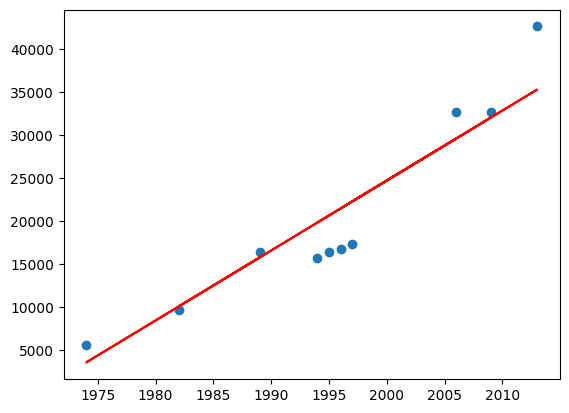

In [73]:
plt.scatter(X_test, y_test)
plt.plot(X_test, lr.predict(X_test), color = "r")

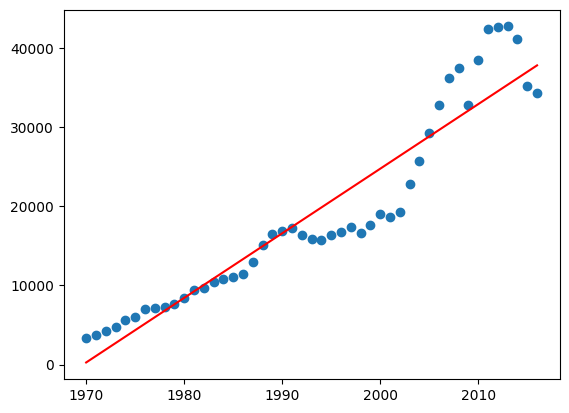

In [74]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color = "r")